# Lifting and Query

Per-frame MaskCLIP features go in; per-vertex features you can query with text come out. Every
3D point projects into every keyframe, keeps the views where its depth agrees with that frame's
depth map, and averages their features weighted by confidence. This page does each step by hand
on the shared scene's points, then reads the `semantics` stage's store on the mesh vertices and
scores two text prompts against it.

In [1]:
import numpy as np
import pyvista as pv
import torch
import trimesh
import zarr

from collab_splats.pointcloud import PointcloudResult
from collab_splats.preproc.frames import frame_idx_from_path, frame_paths
from collab_splats.semantics import (
    FeatureAutoencoder,
    MaskCLIPExtractor,
    read_point_features,
    write_point_features,
)
from collab_splats.semantics.lifting import lift_features, transfer_features
from collab_splats.utils.torch_utils import batch_iterator

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud", "mesh", "semantics")

## 1. Features per frame

The lift reads one feature map per reconstructed frame, in the order the pointcloud stores its
frames. `frame_paths` finds those keyframes in `scene.images_dir` by their source frame index.
MaskCLIP returns a `(D, H_p, W_p)` map per image, one unit-length vector per 14-pixel patch. The
maps stay in memory as float32 for the next two sections.

In [2]:
# The pointcloud with depth and confidence; the lift needs both
cloud = PointcloudResult.load_zarr(scene.pointcloud_zarr, load_world_points=False)

# Keyframe paths in the pointcloud's frame order
frame_ids = []

for name in cloud.image_paths:
    frame_ids.append(frame_idx_from_path(name))

paths = frame_paths(scene.images_dir, frame_ids)

# MaskCLIP over every keyframe, four images per forward pass
extractor = MaskCLIPExtractor()
maps = []

for (batch,) in batch_iterator(4, paths):
    maps.extend(extractor.forward(batch))

stacked = torch.stack(maps)
gib = stacked.nbytes / 2**30
print(f"{len(maps)} maps of {tuple(maps[0].shape)}, {gib:.2f} GiB as float32")

96 maps of (768, 73, 41), 0.82 GiB as float32


## 2. Compressing

MaskCLIP features are 768-D. Storing that per point is costly, so a small autoencoder learns
64-D codes. `fit` trains on every patch of every frame and stops early once the mean
reconstruction cosine reaches `target_cosine`. That cosine is measured on the training patches,
so on a small scene read it as a sign the fit converged, not as held-out accuracy.

In [3]:
# An ndarray trains on the GPU when there is one; a CPU tensor would train on the CPU
features = stacked.numpy()
ae = FeatureAutoencoder(input_dim=features.shape[1], latent_dim=64)
ae.fit(features, epochs=20, target_cosine=0.95)
print(f"reconstruction cosine {ae.recon_cosine:.3f} after {ae.epochs_run} epochs")

# Each frame's map encoded to (64, H_p, W_p) codes on the CPU
ae.cpu()
codes = []

with torch.no_grad():
    for fmap in maps:
        codes.append(ae.encode(fmap))

reconstruction cosine 0.950 after 18 epochs


## 3. Lifting onto points

`lift_features` takes a per-frame loader (here `codes.__getitem__`) and the pointcloud. A point
seen by no frame falls back to the feature at its own source pixel, which every point of a
feedforward reconstruction has. Lifting the 64-D codes rather than the 768-D features keeps the
per-point sums small; reading the store decodes them back.

`write_point_features` writes the codes as float16 with the autoencoder beside them, and
`read_point_features` returns unit-length 768-D features.

In [4]:
# Codes onto every point: depth-checked, confidence-weighted mean over the frames
point_codes = lift_features(codes.__getitem__, cloud)
point_codes = point_codes.numpy()

# Round trip through a lifted store in this page's work directory
store_path = work_dir("lifting_and_query") / "maskclip_lifted.zarr"
write_point_features(store_path, point_codes, ae)
point_features = read_point_features(store_path)
print(f"{len(point_features):,} points: {point_codes.shape[1]}-D codes, "
      f"{point_features.shape[1]}-D features")

500,000 points: 64-D codes, 768-D features


## 4. Querying the mesh

The `semantics` stage does the same lift a second time onto the vertices of `mesh.ply` and
stores the result as `vertex_features` in `maskclip_lifted.zarr`. Vertices have no source pixel,
so a vertex that no frame sees keeps all-zero codes. The store records the mesh's sha256, so a
rebuilt mesh makes the stage run again.

In [5]:
# The stage's lifted store and what it records
lifted = scene.outputs["semantics"]
store = zarr.open(str(lifted), mode="r")
print(store.attrs["extractor"], store.attrs["latent_dim"], store.attrs["mesh_sha256"][:12])

# All-zero raw codes mark unobserved vertices; decoded zeros are not zero
raw = np.asarray(store["vertex_features"])
observed = raw.any(axis=1)
vertex_features = read_point_features(lifted, name="vertex_features")
vertex_features = torch.from_numpy(vertex_features)
print(f"{observed.mean():.1%} of {len(observed):,} vertices observed")

maskclip 64 4d964514cb88


98.1% of 293,707 vertices observed


`score_queries` compares each vertex with the positive prompt and the negatives and returns a
score in [0, 1]. As on the feature extraction page, the negatives name the other things in the
scene; against "object" alone, "tree" scores near 0.5 across the whole mesh. It takes the maximum over its positives, so each prompt
gets its own call. `transfer_features` then spreads each observed vertex's score over its 8
nearest vertices with a Gaussian weight, which smooths patch-sized noise and fills small gaps.

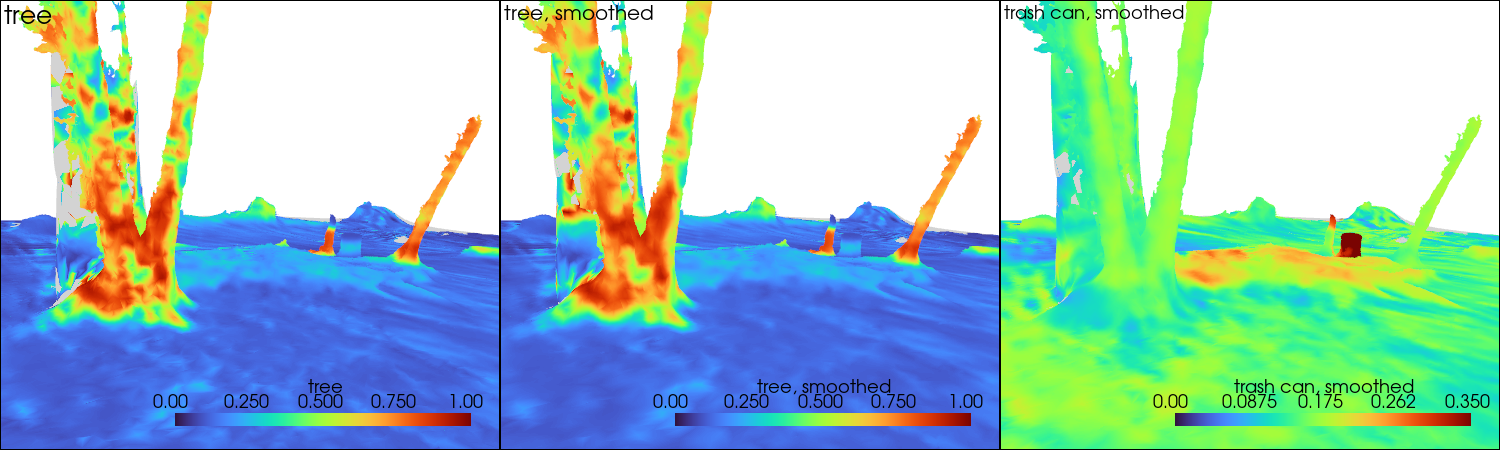

In [6]:
# One contrastive score per vertex for each prompt
NEGATIVES = ["object", "background", "ground", "sky"]
tree = extractor.score_queries(vertex_features, positive=["tree"], negative=NEGATIVES)
can = extractor.score_queries(vertex_features, positive=["trash can"], negative=NEGATIVES)
tree = tree.cpu().numpy()
can = can.cpu().numpy()
scores = np.stack([tree, can], axis=1)

# Observed vertices' scores spread onto the mesh vertices
mesh = trimesh.load(scene.outputs["mesh"], process=False)
vertices = np.asarray(mesh.vertices, dtype=np.float32)
smoothed = transfer_features(vertices, vertices[observed], scores[observed], k=8)

# Vertices no score reached are drawn grey
tree[~observed] = np.nan
reached = smoothed.any(axis=1)
smoothed[~reached] = np.nan

# Raw and smoothed "tree", then smoothed "trash can" on its own, lower color range
surface = pv.wrap(mesh)
panels = [
    ("tree", tree, (0, 1)),
    ("tree, smoothed", smoothed[:, 0], (0, 1)),
    ("trash can, smoothed", smoothed[:, 1], (0, 0.35)),
]
plotter = pv.Plotter(shape=(1, 3), window_size=(1500, 450))

for i, (title, values, clim) in enumerate(panels):
    panel = surface.copy()
    plotter.subplot(0, i)
    plotter.add_text(title, font_size=10)
    plotter.add_mesh(
        panel,
        scalars=values,
        cmap="turbo",
        clim=clim,
        nan_color="lightgrey",
        lighting=False,
        scalar_bar_args={"title": title},
    )

# Look out of the first keyframe's camera: w2c to c2w, OpenCV axes (y down, z forward)
c2w = np.linalg.inv(cloud.extrinsics[0])
eye = c2w[:3, 3]
plotter.link_views()
plotter.camera_position = [eye, eye + c2w[:3, 2], -c2w[:3, 1]]
plotter.camera.view_angle = 60
plotter.show()

From the first keyframe's viewpoint, the trunks light up for "tree" while the ground stays
low. Smoothing changes little at this distance; it mainly fills the grey, unobserved patches on
the left trunk. "Trash can" never scores high against these negatives, so its panel has its own
0-0.35 range: the bin stands out, and the ground just around it picks up some of its score.

## In a pipeline run

The `semantics` stage extracts features for every keyframe, trains the autoencoder, keeps the
64-D codes in `<scene>/semantics/maskclip_codes.zarr`, and lifts them onto the points and the
mesh vertices into `<backend>/semantics/maskclip_lifted.zarr`. `max_epochs` caps the
autoencoder fit.

```yaml
semantics:
  enabled: true
  extractor: maskclip
  max_epochs: 20
```

To query the result interactively, serve the backend directory in the scene viewer and pick the
store from its Semantics dropdown:

```bash
python -m collab_splats.viewer data/tutorial_scene/vggt_omega --port 8080
```